# Laboratório 1 – Captura de Imagem e Vídeo utilizando OpenCV
**Autores**

Luana Fernandes Recucci RA:11202020038

Lucas Merino  RA:11201721004

Victor Parpinelli Ananias da Silva RA:11072516

**Data de realização**

01 de Junho de 2026

**Data de publicação**

04 de Junho de 2026

# 1. Introdução
O processamento digital de imagens é uma área da computação responsável pela aquisição, manipulação e análise de imagens digitais. Atualmente, essa tecnologia está presente em diversas aplicações, como reconhecimento facial, inspeção industrial, veículos autônomos, sistemas médicos e monitoramento por câmeras.

Neste laboratório foram estudadas as funcionalidades básicas da biblioteca OpenCV para leitura, exibição e gravação de imagens e vídeos. Também foram realizadas operações utilizando arquivos armazenados em disco e imagens capturadas diretamente por uma webcam.
Além disso, foram desenvolvidas modificações nos programas fornecidos para compreender melhor o funcionamento da captura de imagens, controle de velocidade de exibição e gravação de vídeos.

# 2. Procedimentos Experimentais
**2.1 Preparação do Ambiente**

Inicialmente foi realizada a instalação do Miniconda e a criação do ambiente virtual CV26, conforme os procedimentos disponibilizados pelo professor. Após a criação do ambiente, foram instaladas as bibliotecas necessárias para a disciplina, incluindo OpenCV, NumPy, Matplotlib, Pillow, Scikit-image, Scikit-learn e Jupyter Notebook.

**2.2 Leitura de Imagem em Arquivo**

Foi executado o programa L__1_img.py, responsável pela leitura de uma imagem armazenada em arquivo e sua exibição em uma janela gráfica.


In [ ]:
import numpy as np
import cv2 as cv

img = cv.imread('messi5.jpg')
#remove parametro que tira a cor
cv.imshow('image',img)
k = cv.waitKey(0)
if k == 27:         # wait for ESC key to exit
    cv.destroyAllWindows()
elif k == ord('s'): # wait for 's' key to save and exit
    cv.imwrite('messigray.png',img)
    cv.destroyAllWindows()


**Discussão**

A imagem não é exibida colorida porque foi carregada utilizando:

img = cv.imread('messi5.jpg',0)

O parâmetro 0 indica ao OpenCV que a imagem deve ser convertida para escala de cinza durante a leitura. Dessa forma, cada pixel passa a ser representado apenas por um nível de intensidade luminosa, eliminando as informações de cor.

**2.3 Leitura de Vídeo em Arquivo**

Foi executado o programa L__2_video.py, responsável pela leitura quadro a quadro de um vídeo armazenado em arquivo.


In [ ]:
import time
import numpy as np
import cv2 as cv

cap = cv.VideoCapture('big_buck_bunny.mp4')

while(cap.isOpened()):
    ret, frame = cap.read()
    
    if ret==True:
        # show the frame
        cv.imshow('frame',frame)

        #wait next frame by 40ms - 25fps
        time.sleep(1/100.0) 
        #mexer no framerate
        
        if cv.waitKey(1) & 0xFF == ord('q'):
            break
    else:
        break
               
cap.release()
cv.destroyAllWindows()


**Alteração da Velocidade de Exibição**

A velocidade de reprodução é controlada principalmente pela instrução:

time.sleep(1/25.0)

Essa linha introduz uma pausa de aproximadamente 40 ms entre os quadros, simulando uma reprodução de 25 quadros por segundo (FPS).
Para aumentar a velocidade, pode-se reduzir o tempo de espera:

time.sleep(1/50.0)

Nesse caso, os quadros serão exibidos em aproximadamente 50 FPS.
Para reduzir a velocidade, pode-se aumentar o tempo de espera:

time.sleep(1/10.0)

Nesse caso, os quadros serão exibidos em aproximadamente 10 FPS.

A velocidade do vídeo depende diretamente do intervalo entre a exibição de quadros consecutivos. Quanto menor o tempo de espera, maior será a quantidade de quadros exibidos por segundo. Quanto maior o tempo de espera, menor será a taxa de atualização e mais lenta parecerá a reprodução.

**2.4 Leitura de Imagens da Webcam**

Foi executado o programa L__3_webcam.py, responsável pela captura contínua de imagens provenientes da webcam.


In [ ]:
import numpy as np
import cv2 as cv

cap = cv.VideoCapture(0)

if not cap.isOpened():
    print("Cannot open camera")
    exit()
    
while True:
    # Capture frame-by-frame
    ret, frame = cap.read()
    # if frame is read correctly ret is True
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break
    
    # Display the resulting frame
    cv.imshow('frame', frame)
    
    if cv.waitKey(1) == ord('x'):
        cv.imwrite('foto.jpg', frame)
        break
    
    if cv.waitKey(1) == ord('q'):
        break

# When everything done, release the capture
cap.release()
cv.destroyAllWindows()


**Resultado Obtido**

O programa acessa a webcam padrão do computador utilizando:

cap = cv.VideoCapture(0)

Em seguida, captura continuamente os quadros da câmera e os exibe em tempo real. O encerramento ocorre quando a tecla q é pressionada.

Para salvar uma imagem quando a tecla x for pressionada, o código pode ser alterado da seguinte forma:

tecla = cv.waitKey(1)

if tecla == ord('x'):
 					   cv.imwrite('foto1.png', frame)

if tecla == ord('q'):
   					 break
Quando a tecla x é pressionada, o quadro armazenado na variável frame é salvo no disco através da função cv.imwrite(). Dessa forma, a imagem capturada pela webcam é armazenada no arquivo "foto1.png".

**Resultado**


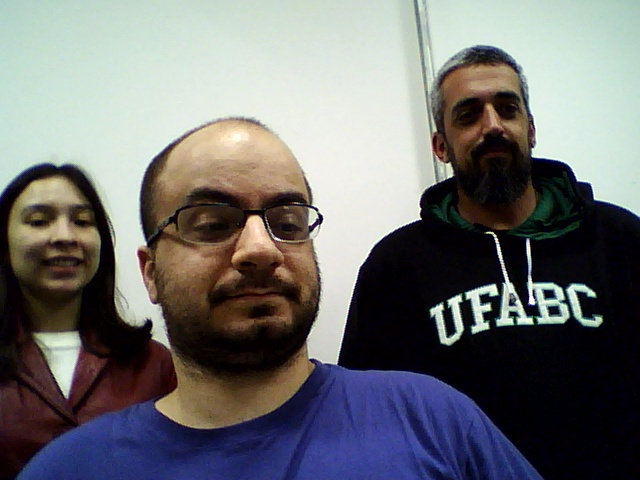

In [1]:
from IPython import display
display.Image("foto.jpg")

**2.5 Gravação de Vídeo da Webcam**

Foi executado o programa L__4_webcap.py, responsável pela gravação das imagens da webcam em um arquivo AVI.

**Código utilizado**


In [ ]:
import numpy as np
import cv2 as cv
cap = cv.VideoCapture(0)

# Get current width of frame
width = cap.get(cv.CAP_PROP_FRAME_WIDTH)   # float
# Get current height of frame
height = cap.get(cv.CAP_PROP_FRAME_HEIGHT) # float
# Define Video Frame Rate in fps
fps = 24.0

# Define the codec and create VideoWriter object
fourcc = cv.VideoWriter_fourcc(*'XVID')
out = cv.VideoWriter('videoObjetoLento.avi', fourcc, fps, (int(width),int(height)) )

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        print("Can't receive frame (stream end?). Exiting ...")
        break
    #frame = cv.flip(frame, 0)
    # write the flipped frame
    out.write(frame)
    cv.imshow('frame', frame)
    if cv.waitKey(1) == ord('q'):
        break

# Release everything if job is finished
cap.release()
out.release()
cv.destroyAllWindows()


**Discussão**

O programa realiza a captura das imagens da webcam e grava os quadros em um arquivo AVI denominado "saida.avi". O codec utilizado é o XVID e a taxa de gravação foi configurada para 10 FPS.

Durante a execução, cada quadro capturado é invertido verticalmente através da função:

    frame = cv.flip(frame, 0)

e posteriormente armazenado no arquivo de vídeo por meio da função:

out.write(frame)

# 3. Parte 2 – Obtenção de Fotos e Vídeos
**3.1 Foto da Equipe**

Foi realizada uma fotografia contendo todos os integrantes da equipe mas um avatar:


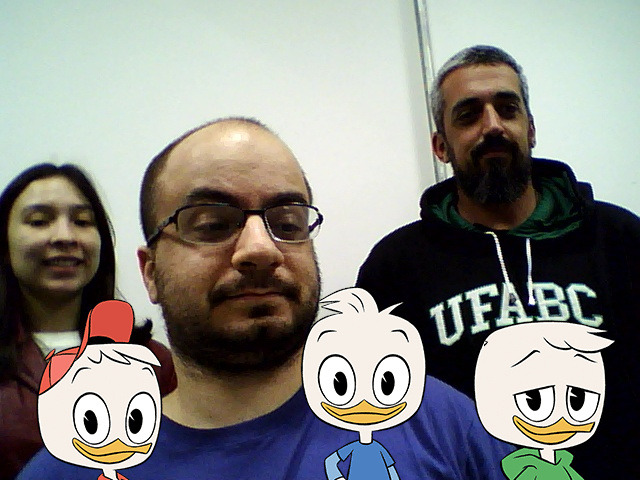

In [2]:
from IPython import display
display.Image("foto_avatar.jpeg")

**3.3 Vídeos Capturados**

Foram produzidos quatro vídeos:

**Vídeo 1 – Pessoa com movimento lento**


In [3]:
from IPython.display import Video

Video("videoPessoaLento.avi")


**Vídeo 2 – Pessoa com movimento rápido**


In [3]:
from IPython.display import Video

Video("videoPessoaRapido.avi")


**Vídeo 3 – Objeto com movimento lento**


In [3]:
from IPython.display import Video

Video("videoObjetoLento.avi")

**Vídeo 3 – Objeto com movimento lento**

In [ ]:
from IPython.display import Video

Video("videoObjetoRapido.avi")

# 4. Análise e Discussão
Os experimentos permitiram compreender as principais etapas de aquisição de imagens utilizando OpenCV. Foram estudadas técnicas de leitura de imagens e vídeos armazenados em arquivos, captura em tempo real através de webcam e gravação de vídeos.

Observou-se que o controle da velocidade de reprodução depende diretamente do intervalo definido entre quadros. Também foi possível verificar a importância da sincronização entre taxa de captura e taxa de gravação para evitar distorções temporais nos vídeos.

Outro aspecto relevante foi a possibilidade de salvar imagens individuais durante a captura em tempo real, recurso amplamente utilizado em aplicações de monitoramento, inspeção e sistemas inteligentes de visão.

# 5. Conclusão
Neste laboratório foram estudadas as operações básicas de aquisição e manipulação de imagens utilizando a biblioteca OpenCV. Os experimentos permitiram compreender o funcionamento da leitura de imagens e vídeos em arquivos, da captura de imagens por webcam e da gravação de vídeos digitais.

As modificações implementadas mostraram como controlar a velocidade de reprodução dos vídeos e como armazenar imagens individuais durante a captura em tempo real. Dessa forma, os objetivos propostos foram atingidos, proporcionando familiaridade com as principais ferramentas que serão utilizadas nos próximos experimentos da disciplina de Visão Computacional.
